<a href="https://colab.research.google.com/github/amoid3203-3009/parkinsons-detection-project/blob/main/src/models/train_lstm_skeleton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 Initializing LSTM Model Skeleton...
📊 Loading Toufiqe's Long Sequence Data...
🔄 Converting long format to AI-ready sequences...
✅ Real Data Ready! Training Data Shape: (628, 1800, 1)
🧠 Building the Neural Network...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)


⚡ Starting Training Phase...
Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 603ms/step - accuracy: 0.6162 - loss: 0.6771 - val_accuracy: 0.6329 - val_loss: 0.6732
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 581ms/step - accuracy: 0.6210 - loss: 0.6686 - val_accuracy: 0.6329 - val_loss: 0.6630
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 589ms/step - accuracy: 0.6242 - loss: 0.6673 - val_accuracy: 0.6329 - val_loss: 0.6588
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 627ms/step - accuracy: 0.6210 - loss: 0.6660 - val_accuracy: 0.6329 - val_loss: 0.6547
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 592ms/step - accuracy: 0.6210 - loss: 0.6658 - val_accuracy: 0.6329 - val_loss: 0.6531
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 585ms/step - accuracy: 0.6210 - loss: 0.6650 - val_accuracy: 0.6329 - val_loss: 0.6510
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 553ms/step - accuracy: 0.6210 - loss: 0.6614 - val_accuracy: 0.6329 - val_loss: 0.6516
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 588ms/step - accuracy: 0.

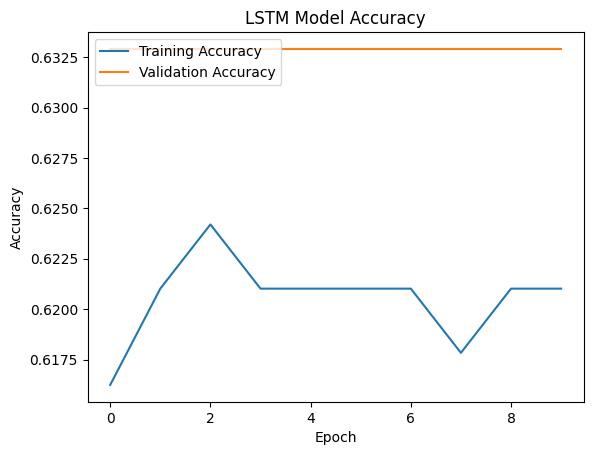

✅ Skeleton Test Complete! Ready for real data.


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

# ==========================================
# 1. SETTINGS & HYPERPARAMETERS
# ==========================================
TIME_STEPS = 50      # How many finger taps we look at in one sequence
FEATURES = 2         # e.g., Left Key, Right Key
BATCH_SIZE = 32
EPOCHS = 10          # Number of times the AI looks at the data

print("🚀 Initializing LSTM Model Skeleton...")

# ==========================================
# 2. DATA LOADING (Mock Data for now)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# ==========================================
# 2. DATA LOADING (Integrating Toufiqe's Long Data)
# ==========================================
print("📊 Loading Toufiqe's Long Sequence Data...")

# 1. Load the "long" CSV
df_long = pd.read_csv('finger_tapping_sequences_long.csv')

# 2. Pivot the data: Group all individual taps back into one row per patient
print("🔄 Converting long format to AI-ready sequences...")
df_wide = df_long.pivot(index=['subject_id', 'recording_id', 'diagnosis', 'hand', 'source_file'],
                        columns='time_step',
                        values='tap_value').fillna(0).reset_index()

# 3. Map Diagnosis to Binary Labels for the AI (1 = Parkinson's, 0 = Healthy)
df_wide['target'] = df_wide['diagnosis'].apply(lambda x: 1 if "Parkinson" in str(x) else 0)
y = df_wide['target'].values

# 4. Drop the text columns so only the pure numeric tapping data remains
metadata_cols = ['subject_id', 'recording_id', 'diagnosis', 'hand', 'source_file', 'target']
X_raw = df_wide.drop(columns=[col for col in metadata_cols if col in df_wide.columns]).values

# 5. Reshape for LSTM: (Samples, Time Steps, Features)
TIME_STEPS = X_raw.shape[1]
FEATURES = 1
X_3D = X_raw.reshape((X_raw.shape[0], TIME_STEPS, FEATURES))

# 6. Split into Training (80%) and Validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X_3D, y, test_size=0.2, random_state=42)

print(f"✅ Real Data Ready! Training Data Shape: {X_train.shape}")

# ==========================================
# 3. BUILD THE LSTM ARCHITECTURE
# ==========================================
print("🧠 Building the Neural Network...")
model = Sequential()

# The LSTM Layer (The 'Memory' block for time-series data)
model.add(LSTM(units=64, input_shape=(TIME_STEPS, FEATURES), return_sequences=False))

# Dropout Layer (Prevents the model from memorizing the data / overfitting)
model.add(Dropout(0.3))

# Output Layer (Binary classification: 1 neuron, sigmoid activation)
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Show a summary of the network in the terminal
model.summary()

# ==========================================
# 4. TRAIN THE MODEL
# ==========================================
print("\n⚡ Starting Training Phase...")
history = model.fit(X_train, y_train,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(X_val, y_val))

# ==========================================
# 5. GENERATE EVALUATION GRAPHS (For your report)
# ==========================================
print("\n📈 Generating Performance Graphs...")

# Plot Training & Validation Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show() # This will pop up a window with the graph for your presentation!

print("✅ Skeleton Test Complete! Ready for real data.")